# Crawling data 


In [1]:
import pandas as pd
import requests
import time
# Crawl data từ Binance API
url = "https://api.binance.com/api/v3/klines"
start_time = 1698796800000  # 2023-11-01 00:00:00 UTC
end_time = 1775001599000    # 2026-03-31 23:59:59 UTC
all_data = []
SYMBOLS = ["BTCUSDT", "ETHUSDT", "SOLUSDT", "BNBUSDT", "LINKUSDT", "AVAXUSDT", "UNIUSDT"]

for symbol in SYMBOLS:
    while start_time < end_time:
            params = {
                "symbol": symbol,
                "interval": "5m", # Chỉnh interval ở đây
                "startTime": start_time,
                "endTime": end_time,
                "limit": 1000
            }
            r = requests.get(url, params=params, timeout=10)
            data = r.json()

            if not data or isinstance(data, dict):
                break

            all_data.extend(data)
            start_time = data[-1][0] + 1
            
            # Cho ngủ 0.3s để đỡ bị rate limit
            time.sleep(0.3)

    # Từ đống bùi nhùi data thô từ API -> DataFrame sạch sẽ đẹp đẽ
    columns = [
        "open_time","open","high","low","close","volume",
        "close_time","quote_volume",
        "num_trades","taker_buy_base",
        "taker_buy_quote","ignore"
    ]

    df = pd.DataFrame(all_data, columns=columns)

    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms")

    for col in ["open","high","low","close","volume"]:
        df[col] = df[col].astype(float)

    df = df[["open_time","open","high","low","close","volume"]]
    df.rename(columns={"open_time": "timestamp"}, inplace=True)
    df.set_index("timestamp", inplace=True)

    # Lưu DataFrame ra file csv
    print(f"Done: {symbol}")
    df.to_csv(f"{symbol}_5m.csv")

KeyboardInterrupt: 

# Model backtest (IS)


In-sample PF 1.0066626340213043 Best Lookback 161
In-Sample MCPT


100%|██████████| 999/999 [21:45<00:00,  1.31s/it]

In-sample MCPT P-Value: 0.792


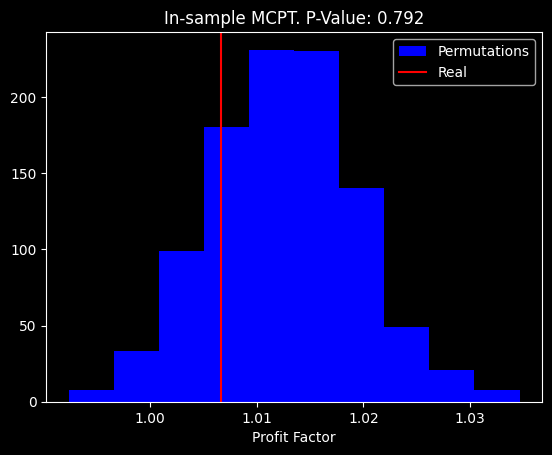

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from donchian import optimize_donchian
from bar_permute import get_permutation
    

df = pd.read_csv('/Users/ad/Desktop/Testing/Stock_research/Data/BTCUSDT_5m.csv', 
                 index_col='timestamp', 
                 parse_dates=True)

train_df = df[(df.index.year >= 2023) & (df.index.year < 2025)]
best_lookback, best_real_pf = optimize_donchian(train_df)
print("In-sample PF", best_real_pf, "Best Lookback", best_lookback)


n_permutations = 1000
perm_better_count = 1
permuted_pfs = []
print("In-Sample MCPT")
for perm_i in tqdm(range(1, n_permutations)):
    train_perm = get_permutation(train_df)
    _, best_perm_pf = optimize_donchian(train_perm)

    if best_perm_pf >= best_real_pf:
        perm_better_count += 1

    permuted_pfs.append(best_perm_pf)

insample_mcpt_pval = perm_better_count / n_permutations
print(f"In-sample MCPT P-Value: {insample_mcpt_pval}")

plt.style.use('dark_background')
pd.Series(permuted_pfs).hist(color='blue', label='Permutations')
plt.axvline(best_real_pf, color='red', label='Real')
plt.xlabel("Profit Factor")
plt.title(f"In-sample MCPT. P-Value: {insample_mcpt_pval}")
plt.grid(False)
plt.legend()
plt.show()

P value show that 

In [25]:
plt.savefig("Donchian_testing_with_permutation_test.jpg")

<Figure size 640x480 with 0 Axes>